In [20]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

In [21]:
df = pd.read_csv("/dataset.csv")

print(df.head())

   Unnamed: 0                track_id                 artists  \
0           0  5SuOikwiRyPMVoIQDJUgSV             Gen Hoshino   
1           1  4qPNDBW1i3p13qLCt0Ki3A            Ben Woodward   
2           2  1iJBSr7s7jYXzM8EGcbK5b  Ingrid Michaelson;ZAYN   
3           3  6lfxq3CG4xtTiEg7opyCyx            Kina Grannis   
4           4  5vjLSffimiIP26QG5WcN2K        Chord Overstreet   

                                          album_name  \
0                                             Comedy   
1                                   Ghost (Acoustic)   
2                                     To Begin Again   
3  Crazy Rich Asians (Original Motion Picture Sou...   
4                                            Hold On   

                   track_name  popularity  duration_ms  explicit  \
0                      Comedy          73       230666     False   
1            Ghost - Acoustic          55       149610     False   
2              To Begin Again          57       210826     False   


In [22]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

In [23]:
print(df.isnull().sum())

Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64


In [24]:
numerical_columns = df.select_dtypes(include=np.number).columns

for col in numerical_columns:
    df[col].fillna(df[col].median(), inplace=True)

categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

print(df.isnull().sum())

/tmp/ipykernel_1482/2078319107.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_1482/2078319107.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

Unnamed: 0          0
track_id            0
artists             0
album_name          0
track_name          0
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64


In [25]:
label_encoder = LabelEncoder()

for col in categorical_columns:
    df[col] = label_encoder.fit_transform(df[col])

print(df.head())

   Unnamed: 0  track_id  artists  album_name  track_name  popularity  \
0           0     62846    10357        8100       11741          73   
1           1     55668     3287       14796       22528          55   
2           2     19766    12397       39162       60774          57   
3           3     77942    14839        8580        9580          71   
4           4     68242     5255       16899       25689          82   

   duration_ms  explicit  danceability  energy  ...  loudness  mode  \
0       230666     False         0.676  0.4610  ...    -6.746     0   
1       149610     False         0.420  0.1660  ...   -17.235     1   
2       210826     False         0.438  0.3590  ...    -9.734     1   
3       201933     False         0.266  0.0596  ...   -18.515     1   
4       198853     False         0.618  0.4430  ...    -9.681     1   

   speechiness  acousticness  instrumentalness  liveness  valence    tempo  \
0       0.1430        0.0322          0.000001    0.3580    0.

In [26]:
scaler = StandardScaler()

df[numerical_columns] = scaler.fit_transform(df[numerical_columns])

print(df.head())

   Unnamed: 0  track_id  artists  album_name  track_name  popularity  \
0   -1.732036     62846    10357        8100       11741    1.782627   
1   -1.732005     55668     3287       14796       22528    0.975633   
2   -1.731975     19766    12397       39162       60774    1.065299   
3   -1.731944     77942    14839        8580        9580    1.692961   
4   -1.731914     68242     5255       16899       25689    2.186125   

   duration_ms  explicit  danceability    energy  ...  loudness      mode  \
0     0.024575     False      0.629244 -0.717148  ...  0.300828 -1.326281   
1    -0.730859     False     -0.845908 -1.889980  ... -1.784744  0.753988   
2    -0.160332     False     -0.742186 -1.122669  ... -0.293288  0.753988   
3    -0.243214     False     -1.733304 -2.312994  ... -2.039252  0.753988   
4    -0.271919     False      0.295030 -0.788711  ... -0.282750  0.753988   

   speechiness  acousticness  instrumentalness  liveness   valence     tempo  \
0     0.551848     -0.85

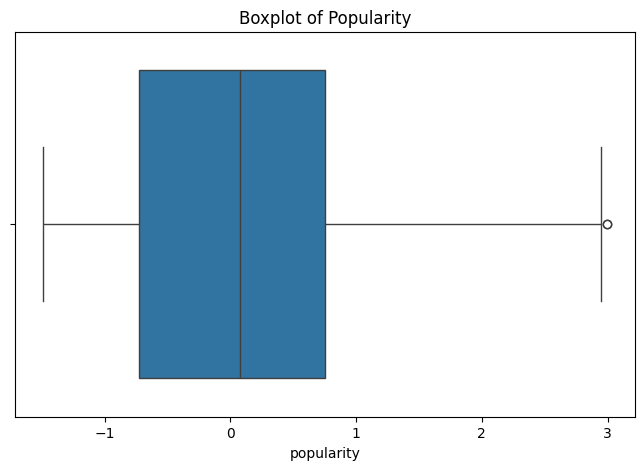

In [27]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["popularity"])

plt.title("Boxplot of Popularity")

plt.show()

In [28]:
Q1 = df["popularity"].quantile(0.25)

Q3 = df["popularity"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df["popularity"] >= lower_bound) &
        (df["popularity"] <= upper_bound)]

print(df.shape)

(113998, 21)


In [30]:
df = df.head(5000)

df.to_csv("cleaned_spotify_small.csv", index=False)

print("Smaller dataset saved")

Smaller dataset saved


In [31]:
df.to_csv("cleaned_spotify.csv", index=False)

print("Dataset Saved Successfully")

Dataset Saved Successfully


In [33]:
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,-1.732036,62846,10357,8100,11741,1.782627,0.024575,False,0.629244,-0.717148,...,0.300828,-1.326281,0.551848,-0.850202,-0.504109,0.758743,0.929306,-1.141863,0.221823,0
1,-1.732005,55668,3287,14796,22528,0.975633,-0.730859,False,-0.845908,-1.889980,...,-1.784744,0.753988,-0.078993,1.831732,-0.504094,-0.591211,-0.798690,-1.489717,0.221823,0
2,-1.731975,19766,12397,39162,60774,1.065299,-0.160332,False,-0.742186,-1.122669,...,-0.293288,0.753988,-0.273826,-0.315499,-0.504112,-0.507167,-1.365688,-1.528312,0.221823,0
3,-1.731944,77942,14839,8580,9580,1.692961,-0.243214,False,-1.733304,-2.312994,...,-2.039252,0.753988,-0.457309,1.774593,-0.503883,-0.428376,-1.276974,1.987859,-2.089680,0
4,-1.731914,68242,5255,16899,25689,2.186125,-0.271919,False,0.295030,-0.788711,...,-0.282750,0.753988,-0.303145,0.463399,-0.504112,-0.686285,-1.184403,-0.073348,0.221823,0
